In [ ]:
# Enable autoreload of local Python modules (e.g., models)
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time

# local imports
import models as models
import generation as generation


In [3]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [4]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./text8_train.txt", "r") as f:
    train_text = f.read()
with open("./text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [5]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [6]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [6]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

entially all of the world s writing systems see unicode and bob bemer codes to detect or correct errors e g in storage or transm

on although any relationship thereto is based on modern borrowing of discrete facets derived from recent historical and archaelo

vance guerrilla warfare in the chinese civil war both before and after the sino japanese war there was continuous fighting betwe

ally a large part of the territory of the present day azerbaijan republic has been called arran named after arran a legendary fo

 be found in jersey only fragmentary wall paintings remain from the rich mediaeval artistic heritage after the wholesale iconocl



# Create a basic Transformer model

In [7]:
def create_train_state(rng, vocab_size=27, d_model=64, n_layers=6, n_heads=8, max_len=128):
    # create a basic Transformer model
    model = models.DecoderOnlyTransformer(vocab_size, d_model, n_layers, n_heads, max_len)
    # create a dummy input for initialization
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    # pass the dummy input to the model to initialize the parameters
    params = model.init({"params": rng}, dummy)["params"]
    return model, params

In [8]:
# vocab size
vocab_size= len(char_set)

# internal model dimensions
d_model=256

# number of attention heads
n_heads=8

# number of Transformer layers
n_layers=2

# maximum sequence length
max_len=128

model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len)

In [9]:
# compute the number of parameters
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 1_624_576


In [10]:
# sanity check: create a batch of data & run a forward pass
B, T = 4, 32
batch = jax.random.randint(
    key=key,
    shape=(B, T), minval=0, maxval=len(char_set))
logits = model.apply({"params": params}, batch)

print("batch shape:", batch.shape)  # (B, T)
print("logits shape:", logits.shape)  # (B, T, vocab_size)

batch shape: (4, 32)
logits shape: (4, 32, 27)


# Loss function

In [11]:
@jax.jit
def loss_and_metrics(logits, targets):
    """Compute cross-entropy loss and accuracy.

    Assumes `targets` contains only valid integer class ids in [0, V-1] (no -1 ignore tokens).

    Args:
      logits: (B, T, V) float array of unnormalized scores.
      targets: (B, T) integer array with ground-truth class ids.

    Returns:
      loss: scalar average cross-entropy over all positions.
      metrics: dict with keys "loss" and "acc" (both scalars).
    """
    # Flatten batch/time dims so optax works on shape (N, V) and (N,)
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)

    # Per-position cross-entropy, then mean over all positions
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()

    # prediction over all positions
    preds = jnp.argmax(logits, axis=-1)  # (B, T)

    # compute accuracy over only the last position
    is_match = preds == targets

    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))

    # Accuracy over only last position
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:,-1])

    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}

# Optimization step:

In [16]:
def transformer_lr_schedule(d_model, warmup_steps=4000):
    """Noam learning rate schedule from 'Attention Is All You Need'.

    lrate = d_model^{-0.5} * min(step^{-0.5}, step * warmup^{-1.5})
    """
    def schedule(step):
        # step 从 0 开始，这里确保不会除以 0
        step = jnp.maximum(step, 1)

        inv_sqrt_step = step ** -0.5
        scaled_step = step * (warmup_steps ** -1.5)

        return (d_model ** -0.5) * jnp.minimum(inv_sqrt_step, scaled_step)

    return schedule


In [21]:
def train_step(params, opt_state, x, y, tx, rng):
    """Single optimization step using optax optimizer.

    Args:
      params: pytree of model parameters.
      opt_state: optax optimizer state.
      x, y: (B, T) int32.
      tx: optax optimizer (static).
      rng: jax.random.PRNGKey for dropout.

    Returns:
      new_params, new_opt_state, metrics, new_rng
    """
    # 为本次step生成一个专门给dropout用的子key
    rng, dropout_rng = jax.random.split(rng)

    def loss_fn(params):
        logits = model.apply(
            {"params": params},
            x,
            deterministic=False,                  # 训练时启用dropout
            rngs={"dropout": dropout_rng},        # 关键：给Dropout提供rng
        )
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    updates, new_opt_state = tx.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    # 把更新后的rng一并返回，供下一步使用
    return new_params, new_opt_state, metrics, rng

# 仍然只把 tx 作为 static arg
train_step = jax.jit(train_step, static_argnames=("tx",))


# Batch creation:

In [22]:
# create a batch from the training data
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.

    Args:
      text_int: 1D array of token ids.
      B: batch size (number of sequences).
      T: sequence length (number of tokens per sequence).

    Returns:
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

# Optimizer creation:

In [23]:
warmup_steps = 4000

# Noam learning rate schedule
learning_rate_schedule = transformer_lr_schedule(d_model=d_model,
                                                 warmup_steps=warmup_steps)

# Adam with Transformer-paper hyperparameters
tx = optax.adam(
    learning_rate=learning_rate_schedule,  # 注意这里传的是函数，不是常数
    b1=0.9,
    b2=0.98,
    eps=1e-9,
)

# Initialize optimizer state for current params
opt_state = tx.init(params)
print(f"Initialized optimizer: Adam with Noam schedule, "
      f"d_model={d_model}, warmup_steps={warmup_steps}")


Initialized optimizer: Adam with Noam schedule, d_model=256, warmup_steps=4000


In [26]:
niter = 100_000
B, T = 128, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()

for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]

    # 这里把 key 传给 train_step，并接收更新后的 new_key
    params, opt_state, metrics, key = train_step(
        params, opt_state, input, target, tx, key
    )

    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']

    loss_history.append(loss)
    time_history.append(time.time() - time_start)

    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]

        # 测试/验证时 deterministic=True，不需要 dropout rng
        test_logits = model.apply(
            {"params": params},
            test_input,
            deterministic=True,
        )
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']

        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): "
              f"{100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 0.1 seconds
	 	 loss(train :: test): 3.9270 :: 3.9309
	 	 accuracy (train :: test): 2.2% :: 2.3%
	 	 accuracy (last character) (train :: test): 1.6% :: 1.8%

iteration 2_000  time: 46.4 seconds
	 	 loss(train :: test): 1.7496 :: 1.6958
	 	 accuracy (train :: test): 46.2% :: 48.4%
	 	 accuracy (last character) (train :: test): 57.8% :: 48.4%

iteration 4_000  time: 84.6 seconds
	 	 loss(train :: test): 1.6575 :: 1.5662
	 	 accuracy (train :: test): 49.6% :: 51.7%
	 	 accuracy (last character) (train :: test): 44.5% :: 51.2%

iteration 6_000  time: 124.4 seconds
	 	 loss(train :: test): 1.5108 :: 1.4764
	 	 accuracy (train :: test): 52.9% :: 54.1%
	 	 accuracy (last character) (train :: test): 50.8% :: 54.5%

iteration 8_000  time: 163.6 seconds
	 	 loss(train :: test): 1.4415 :: 1.4445
	 	 accuracy (train :: test): 54.8% :: 55.2%
	 	 accuracy (last character) (train :: test): 57.8% :: 59.9%

iteration 10_000  time: 202.6 seconds
	 	 loss(train :: test): 1.4853 :: 1.44

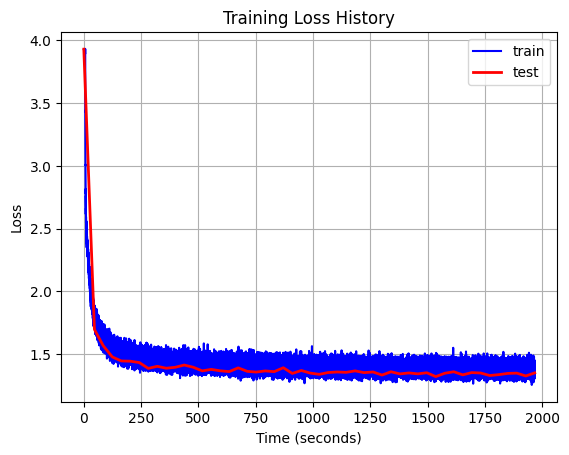

In [27]:
# plot the loss history
import matplotlib.pyplot as plt
plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

In [30]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
# prompt_int = encode(prompt.lower())
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64,
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my fri il alilido as a o shokiter mallinigaphaninin frpals choz ouchalo c a cane m a prus mondgho ime bi palinse on s ononade liay ccopusthis acithongon ar iche an thanicary aryl us ary wande bis tollk anananitexithex ont ins on o the thor icthate s ongollycole s oge f wan orucoprespaccca rs ilocaboges t ccconess onse onone thie on ar se pinsest bolyliordiess opseux tr ar wan chan sbus an ongede fffffin alonde wanitat ed ano ffff wanescteniad it cccccoroniminict it denal s limiembortones binalichies t ke ochate t s ichin opun c mis o t es ga the ore ononicccccaner sigs urinoluthade iove se ycin pare lin rylistranin an arutrinaus a athasstane a aminimonan l waterallin buranskalinoust put shoner ccctere ffffte pane s ispesbininscthalllanghorones ar thoringedede ate anes ored an inshe ispanin act acr s the othimex chan an bimprylsstharylin s m ess mpidd att thogin ir c ophopola d ins ps otreme t han a esiol a wini a othethins misops s o